# 01 — EDA

Thin notebook (PLAN.md §6): loads the frozen `corpus_v1.parquet` (built by
T1.8) and produces the first two required EDA figures (PLAN.md §7,
Figure 1): the rating distribution and the review-length distribution.
These are also the "Understand the problem" evidence PLAN.md §3 E0 calls
for, and directly motivate why CRAGB (the benchmark, built later) needs
deliberately-sampled negative/low-star questions rather than relying on
the corpus's natural (heavily positive) rating skew.

This notebook contains no pipeline logic of its own — it reads the
already-built corpus and calls plotting code only.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from cragb.utils.io import load_config, resolve_path

cfg = load_config("configs/data.yaml")
corpus = pd.read_parquet(resolve_path(cfg["paths"]["corpus_out"]))
print(corpus.shape)
corpus[["rating", "token_len"]].describe()

(200000, 20)


,rating,token_len
count,200000.000000,200000.000000
mean,3.843815,64.595030
std,1.400586,77.215665
min,1.000000,1.000000
25%,3.000000,18.000000
50%,5.000000,41.000000
75%,5.000000,84.000000
max,5.000000,1914.000000


## Figure 1a — Rating distribution

`corpus_v1` is a *stratified* sample (T1.7), not the raw corpus — its
20/15/65 split across 1-2/3/4-5 star reviews is a deliberately engineered
property (Risk C in PLAN.md: plain random sampling would leave 1-2 star
"defect/fit" questions almost without evidence). This figure documents
what the frozen corpus actually contains, which is the sampled
distribution, not the raw source distribution.

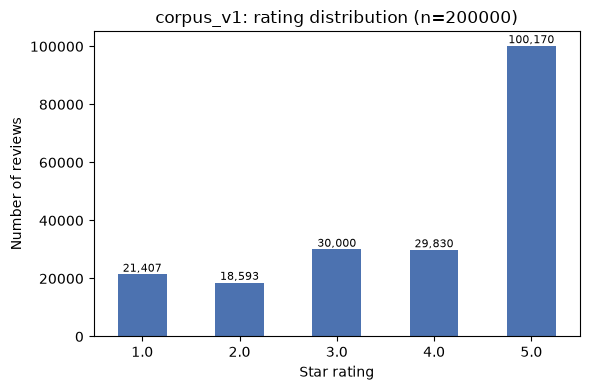

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
corpus["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of reviews")
ax.set_title("corpus_v1: rating distribution (n=%d)" % len(corpus))
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(corpus["rating"].value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig("../reports/figures/eda_rating_dist.png", dpi=150)
plt.show()

## Figure 1b — Review-length distribution

Uses `token_len` (T1.6's regex-based token proxy, not an exact LLM
tokenizer — see `cragb.data.features` docstring for why that distinction
is deliberate at this stage). Plotted on a log-x axis: review length is
strongly right-skewed (many short reviews, a long tail of detailed ones),
so a linear axis would compress almost everything into one bar.

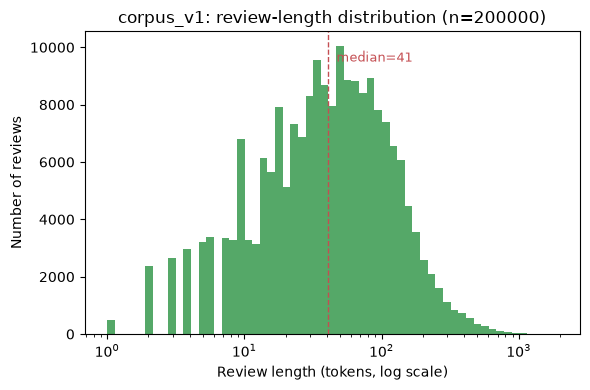

In [3]:
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
# Log-spaced bins: with a log-x axis, linearly-spaced bins render as
# unequal (and misleading) bar widths. np.logspace keeps each bar's
# width visually proportional to its actual token-count range.
bins = np.logspace(0, np.log10(corpus["token_len"].max()), 60)
ax.hist(corpus["token_len"], bins=bins, color="#55A868")
ax.set_xscale("log")
ax.set_xlabel("Review length (tokens, log scale)")
ax.set_ylabel("Number of reviews")
ax.set_title("corpus_v1: review-length distribution (n=%d)" % len(corpus))
median = corpus["token_len"].median()
ax.axvline(median, color="#C44E52", linestyle="--", linewidth=1)
ax.text(median, ax.get_ylim()[1] * 0.9, f"  median={median:.0f}", color="#C44E52", fontsize=9)
fig.tight_layout()
fig.savefig("../reports/figures/eda_length_dist.png", dpi=150)
plt.show()

## Figure 1c — Image coverage

`has_image` (T1.6) is the other forced stratification axis from T1.7
(target 15%/85%). This is the population `corpus_v1` can draw on for
"visual evidence" questions (RQ4 in PLAN.md) — the figure documents that
coverage honestly rather than assuming it.

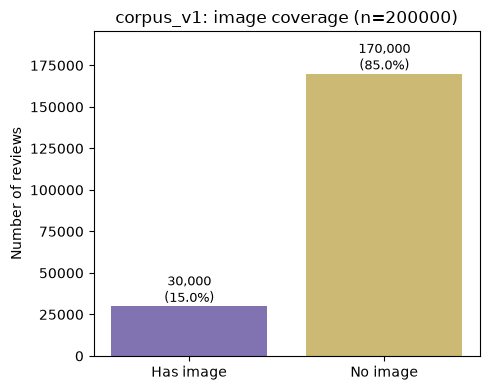

In [4]:
image_counts = corpus["has_image"].value_counts().reindex([True, False])
image_pct = 100 * image_counts / len(corpus)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Has image", "No image"], image_counts.values, color=["#8172B2", "#CCB974"])
ax.set_ylabel("Number of reviews")
ax.set_title("corpus_v1: image coverage (n=%d)" % len(corpus))
ax.set_ylim(0, image_counts.max() * 1.15)  # headroom so bar-top labels clear the title
for i, (count, pct) in enumerate(zip(image_counts.values, image_pct.values)):
    ax.text(i, count, f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig("../reports/figures/eda_image_coverage.png", dpi=150)
plt.show()

## Figure 1d — Reviews per product

Grouped by `parent_asin`. Heavily right-skewed (as expected for review
data: most products get one review, a handful get hundreds), so shown on
a log-y axis with individual bars for low counts (1-15) and a single
"16+" bucket for the long tail, rather than a log-x histogram that would
blur the important 1-vs-2-vs-3 distinction near the origin.

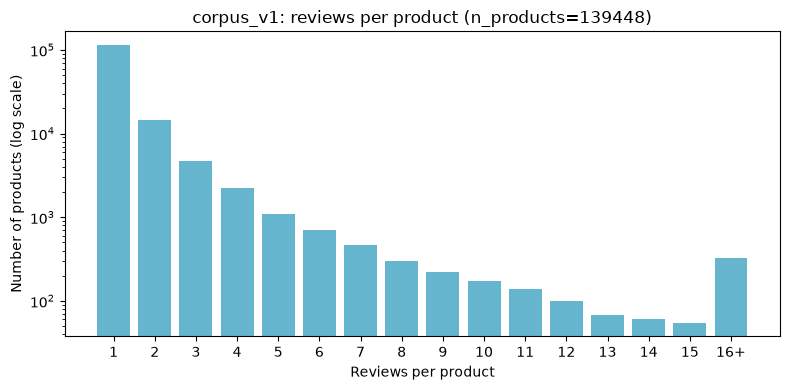

In [5]:
reviews_per_product = corpus.groupby("parent_asin").size()

CAP = 15
capped = reviews_per_product.clip(upper=CAP + 1)  # CAP+1 stands in for "16+"
counts_by_bucket = capped.value_counts().sort_index()
labels = [str(i) for i in range(1, CAP + 1)] + [f"{CAP + 1}+"]
values = [counts_by_bucket.get(i, 0) for i in range(1, CAP + 1)] + [counts_by_bucket.get(CAP + 1, 0)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, values, color="#64B5CD")
ax.set_yscale("log")
ax.set_xlabel("Reviews per product")
ax.set_ylabel("Number of products (log scale)")
ax.set_title("corpus_v1: reviews per product (n_products=%d)" % reviews_per_product.shape[0])
fig.tight_layout()
fig.savefig("../reports/figures/eda_reviews_per_product.png", dpi=150)
plt.show()

## Figure 1e — Sub-category coverage

`main_category` (the raw metadata field) is almost entirely a single
value (`"AMAZON FASHION"`) — a store-level label, not a useful
sub-category. The genuinely informative field is `categories`, a
breadcrumb list (e.g. `["Clothing, Shoes & Jewelry", "Women", "Jewelry",
"Earrings", ...]`); its **second element** (index 1) is the department
level (Women/Men/Girls/Boys/...), which is what "sub-category coverage"
means here. Shown as top-15 + "Other" (the top 15 already cover ~99% of
rows), per PLAN.md §3 E0's "sub-category coverage" EDA requirement — this
is a coverage *check*, not a forced stratification target (T1.7
deliberately doesn't quota sub-category; see `cragb.data.sample` module
docstring).

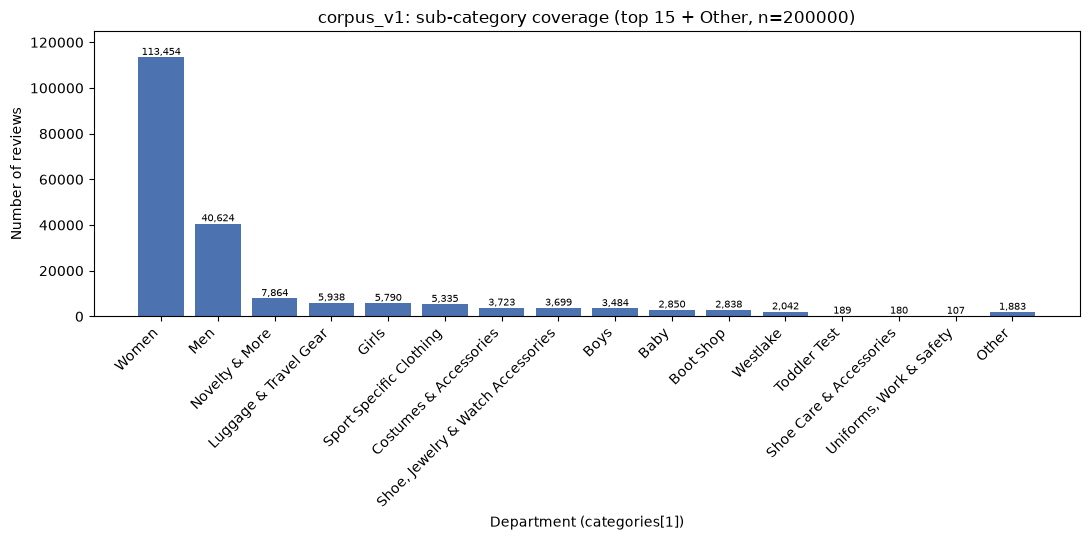

In [6]:
def department(categories) -> str | None:
    return categories[1] if len(categories) > 1 else None

dept = corpus["categories"].map(department)
top_n = 15
top_depts = dept.value_counts().head(top_n)
other_count = len(corpus) - top_depts.sum()

plot_counts = pd.concat([top_depts, pd.Series({"Other": other_count})])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(range(len(plot_counts)), plot_counts.values, color="#4C72B0")
ax.set_xticks(range(len(plot_counts)))
ax.set_xticklabels(plot_counts.index, rotation=45, ha="right")
ax.set_xlabel("Department (categories[1])")
ax.set_ylabel("Number of reviews")
ax.set_title(f"corpus_v1: sub-category coverage (top {top_n} + Other, n={len(corpus)})")
ax.set_ylim(0, plot_counts.max() * 1.1)
for i, v in enumerate(plot_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=7)
fig.tight_layout()
fig.savefig("../reports/figures/eda_subcategory_coverage.png", dpi=150)
plt.show()

## Summary statistics (for the datasheet / report text)

In [7]:
summary = {
    "n_reviews": len(corpus),
    "rating_mean": round(corpus["rating"].mean(), 3),
    "rating_counts": corpus["rating"].value_counts().sort_index().to_dict(),
    "token_len_median": int(corpus["token_len"].median()),
    "token_len_mean": round(corpus["token_len"].mean(), 1),
    "token_len_p95": int(corpus["token_len"].quantile(0.95)),
    "token_len_max": int(corpus["token_len"].max()),
    "image_coverage_pct": round(100 * corpus["has_image"].mean(), 2),
    "n_unique_products": int(corpus["parent_asin"].nunique()),
    "reviews_per_product_median": float(reviews_per_product.median()),
    "reviews_per_product_max": int(reviews_per_product.max()),
    "n_unique_departments": int(dept.nunique()),
    "top5_departments_share_pct": round(100 * dept.value_counts().head(5).sum() / len(corpus), 1),
}
summary

{'n_reviews': 200000,
 'rating_mean': np.float64(3.844),
 'rating_counts': {1.0: 21407,
  2.0: 18593,
  3.0: 30000,
  4.0: 29830,
  5.0: 100170},
 'token_len_median': 41,
 'token_len_mean': np.float64(64.6),
 'token_len_p95': 195,
 'token_len_max': 1914,
 'image_coverage_pct': np.float64(15.0),
 'n_unique_products': 139448,
 'reviews_per_product_median': 1.0,
 'reviews_per_product_max': 843,
 'n_unique_departments': 371,
 'top5_departments_share_pct': np.float64(86.8)}